In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
import os
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
notebook_dir = os.getcwd()
path_to_processed_datasets = os.path.join(notebook_dir, '..', 'data', 'processed', 'stroke_processed.csv')

In [3]:
stroke_processed_data = pd.read_csv(path_to_processed_datasets )

In [8]:
stroke_processed_data.sample(10)

,Unnamed: 0,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
562,621,42553,Female,80.0,False,False,Yes,Private,Rural,148.91,28.3,never smoked,False
2867,3388,52679,Female,82.0,False,False,Yes,Self-employed,Rural,78.00,31.3,formerly smoked,False
2925,3462,31344,Male,82.0,False,False,Yes,Self-employed,Urban,214.51,24.0,formerly smoked,False
3947,4722,54395,Female,78.0,True,False,Yes,Self-employed,Rural,152.38,31.8,never smoked,False
3074,3639,61475,Female,51.0,True,False,Yes,Private,Rural,85.84,31.8,never smoked,False
2751,3245,71597,Female,79.0,True,False,Yes,Private,Rural,64.44,26.9,formerly smoked,False
542,596,52063,Female,53.0,False,False,Yes,Self-employed,Urban,71.15,26.1,formerly smoked,False
1331,1542,24219,Male,25.0,False,False,Yes,Private,Urban,93.51,30.8,never smoked,False
2279,2686,50485,Male,54.0,False,False,Yes,Private,Rural,227.74,33.4,smokes,False
8,8,27419,Female,59.0,False,False,Yes,Private,Rural,76.15,29.2,Unknown,True


Analysing feature Unnamed: 0
Skewness of Unnamed: 0 is 0.02279807079724504


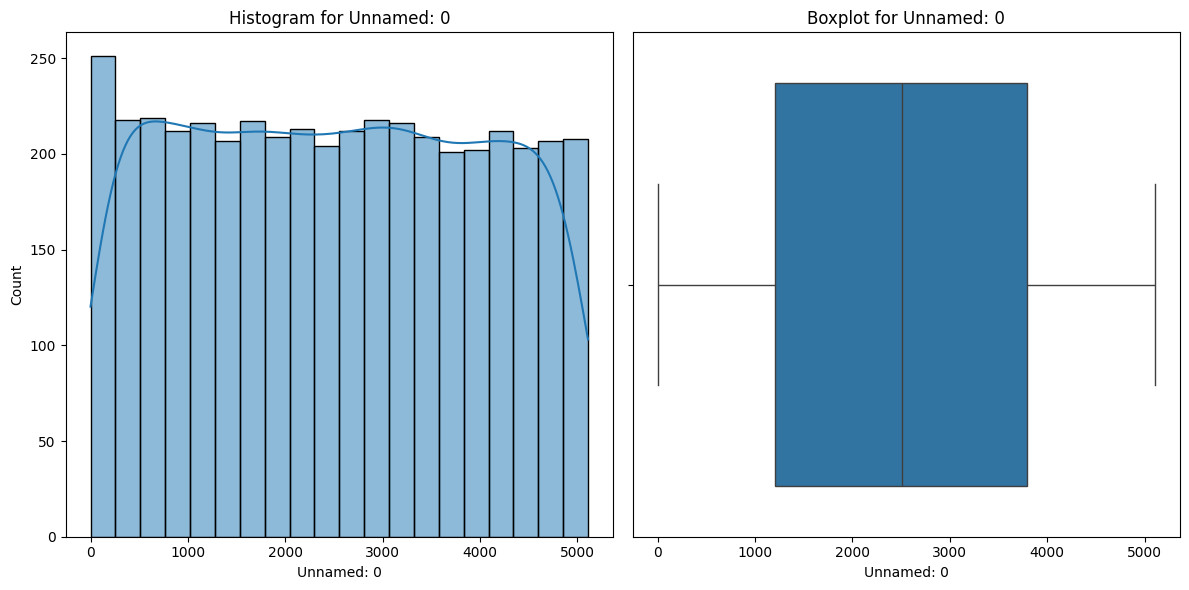

Analysing feature id
Skewness of id is -0.024508916889098658


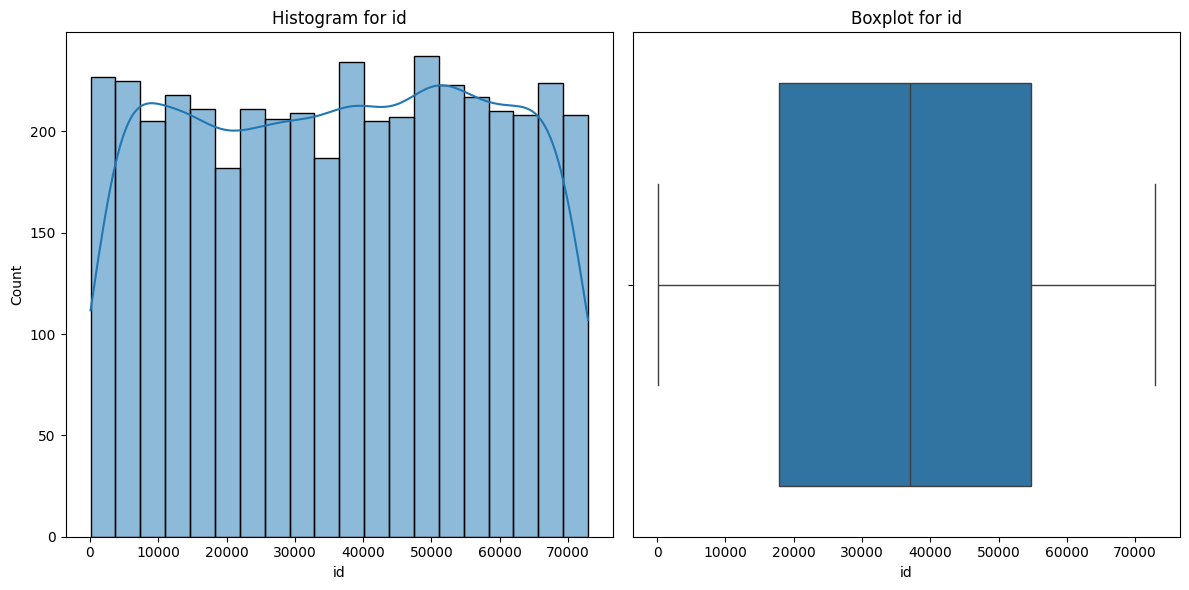

Analysing feature gender
gender is categorical/non-numeric, skipping skewness


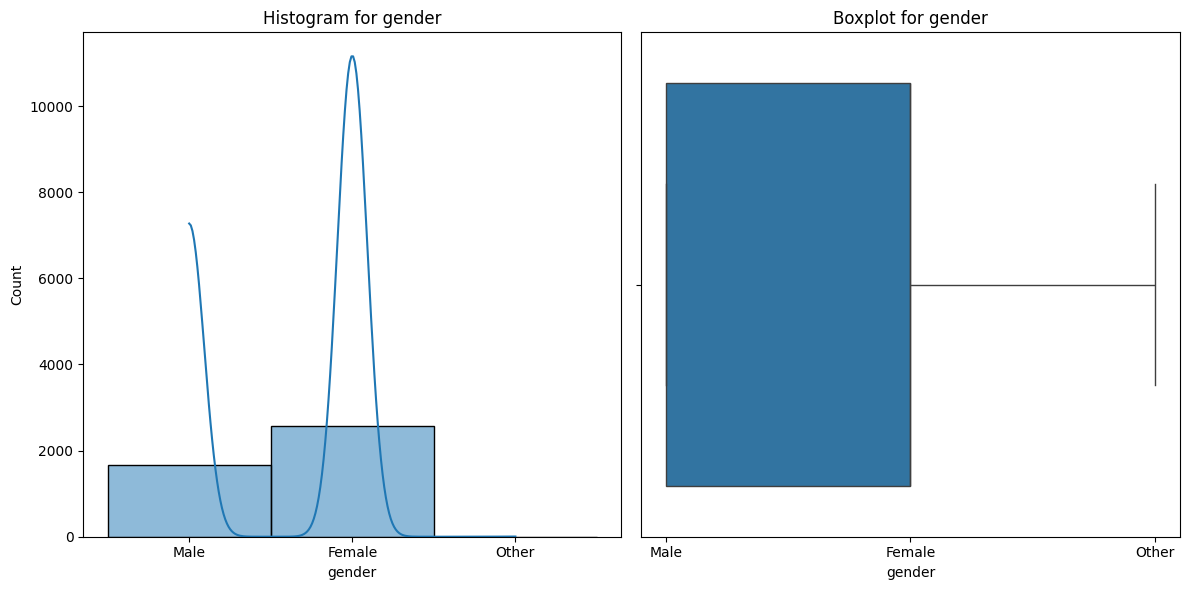

Analysing feature age
Skewness of age is 0.016846283195934342


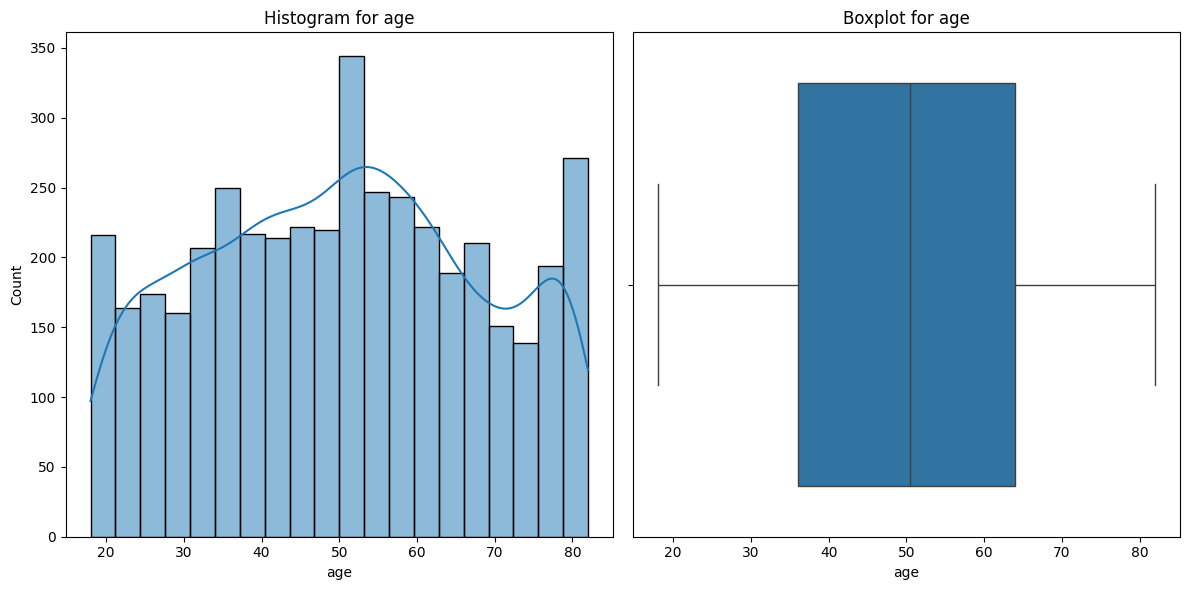

Analysing feature hypertension
Skewness of hypertension is 2.385716356892266


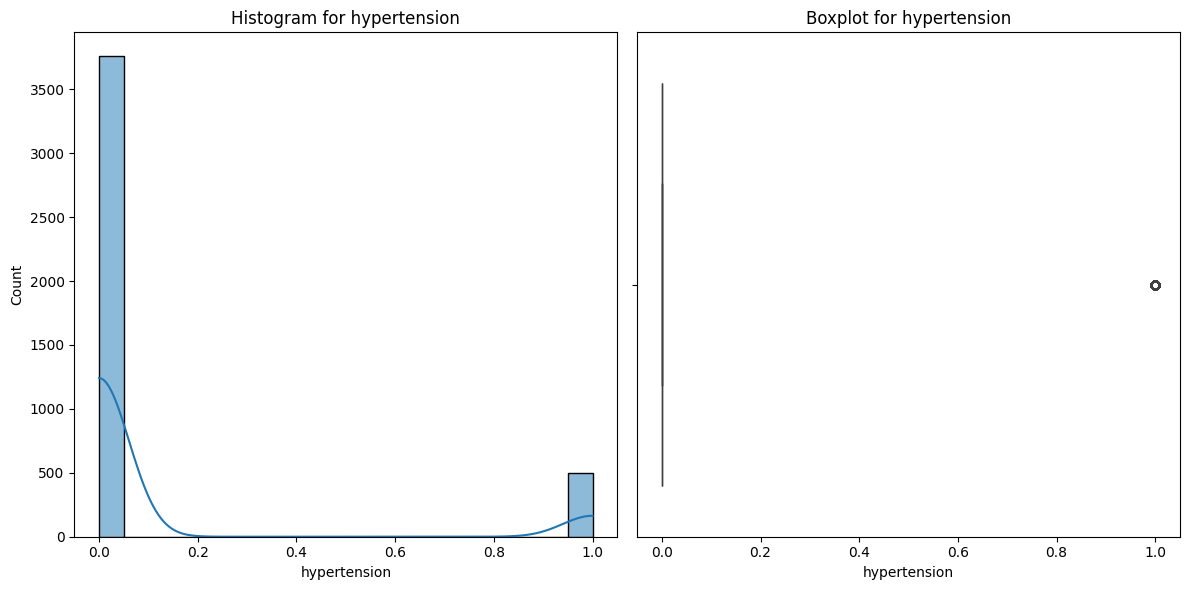

Analysing feature heart_disease
Skewness of heart_disease is 3.54093261041687


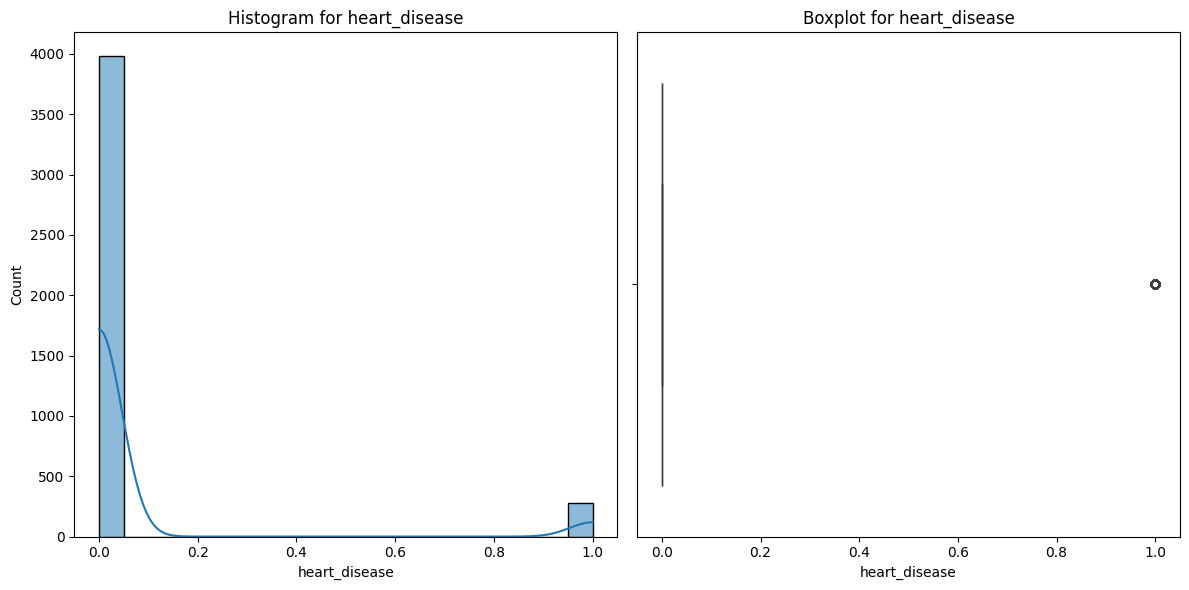

Analysing feature ever_married
ever_married is categorical/non-numeric, skipping skewness


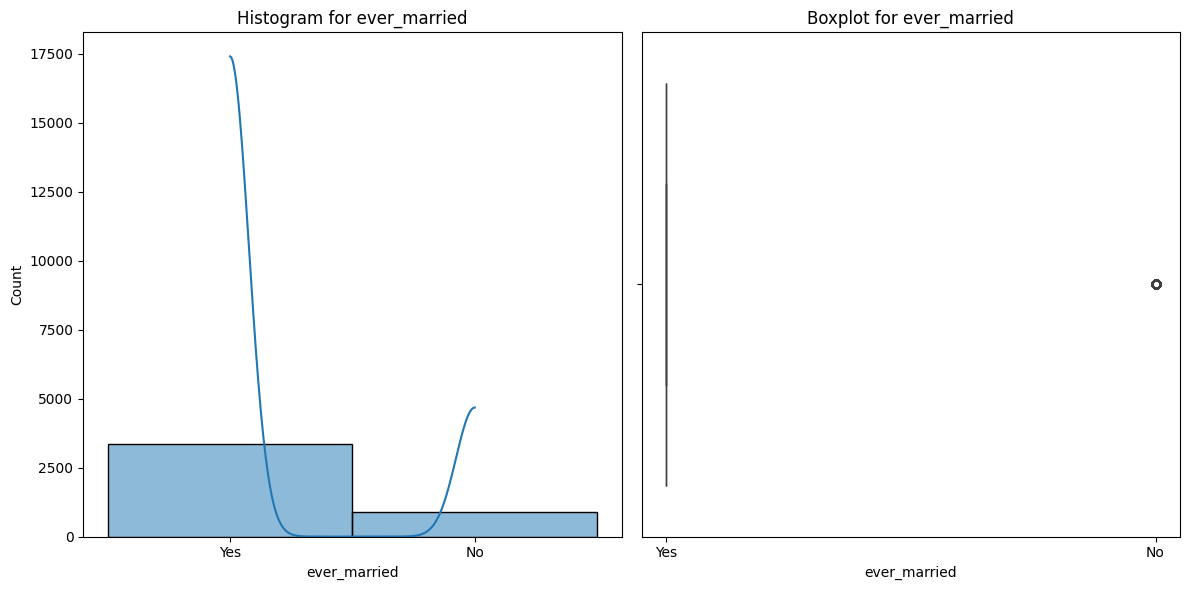

Analysing feature work_type
work_type is categorical/non-numeric, skipping skewness


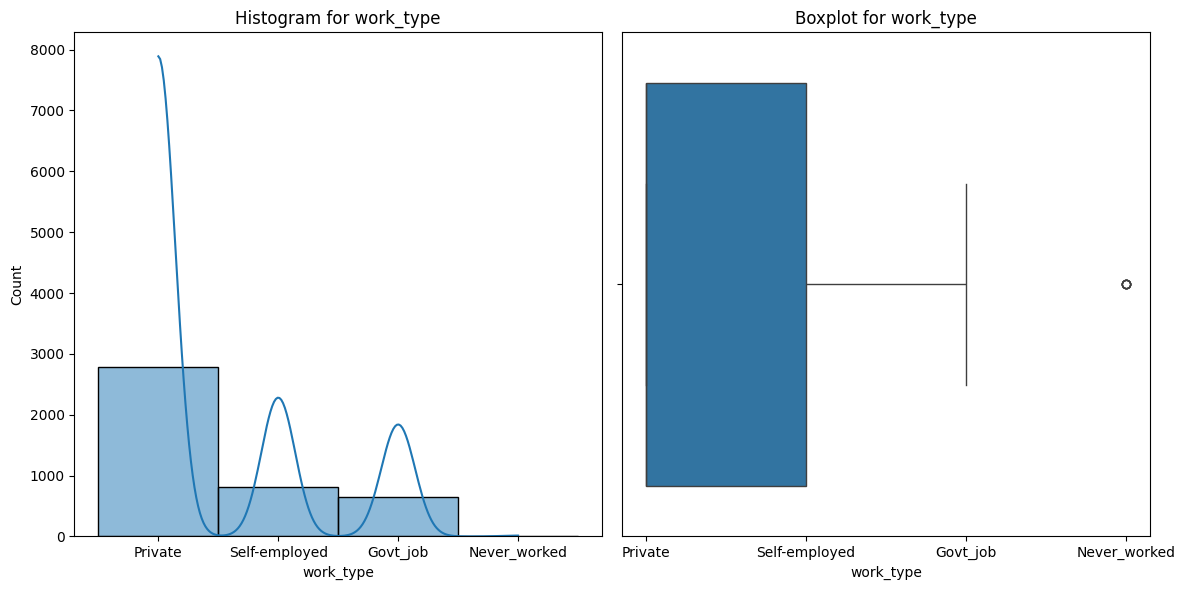

Analysing feature Residence_type
Residence_type is categorical/non-numeric, skipping skewness


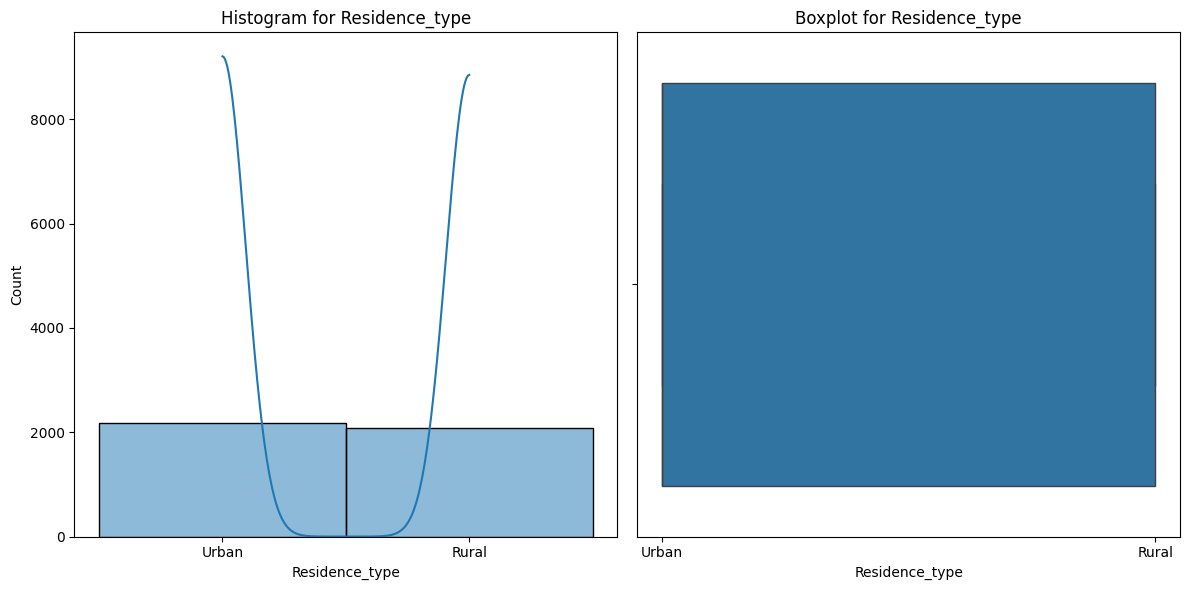

Analysing feature avg_glucose_level
Skewness of avg_glucose_level is 1.4586410459219736


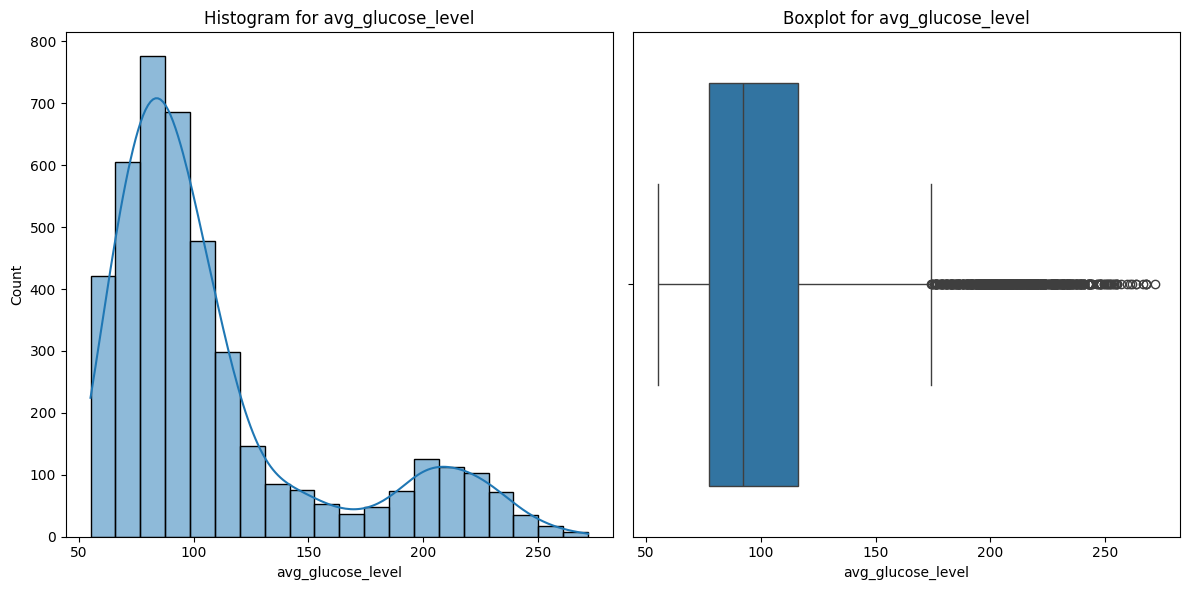

Analysing feature bmi
Skewness of bmi is 1.282024379689572


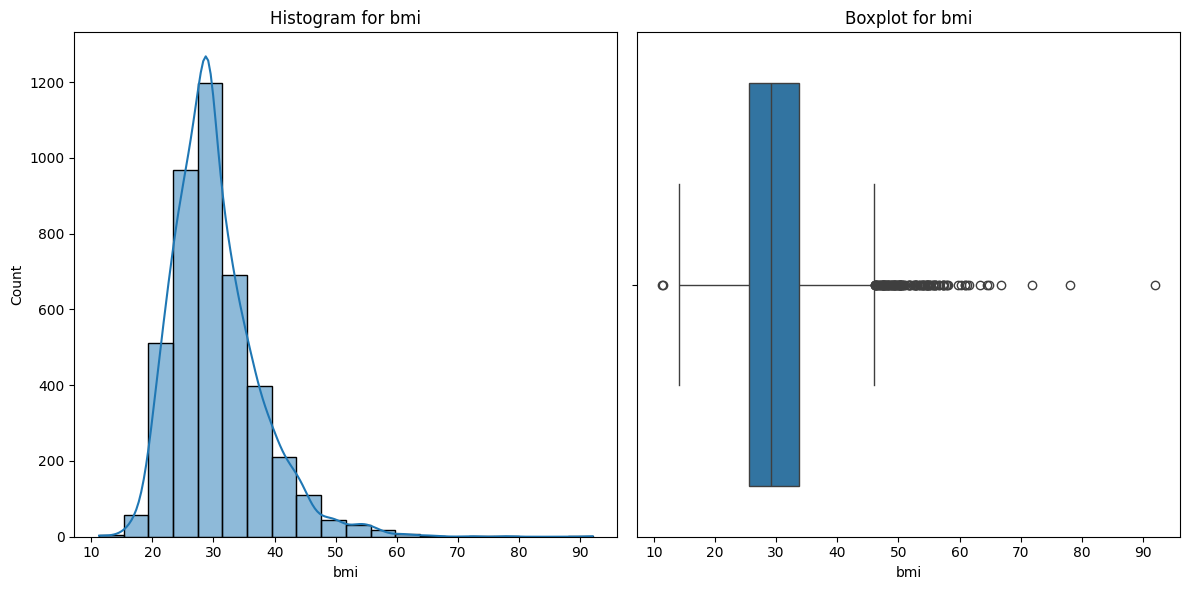

Analysing feature smoking_status
smoking_status is categorical/non-numeric, skipping skewness


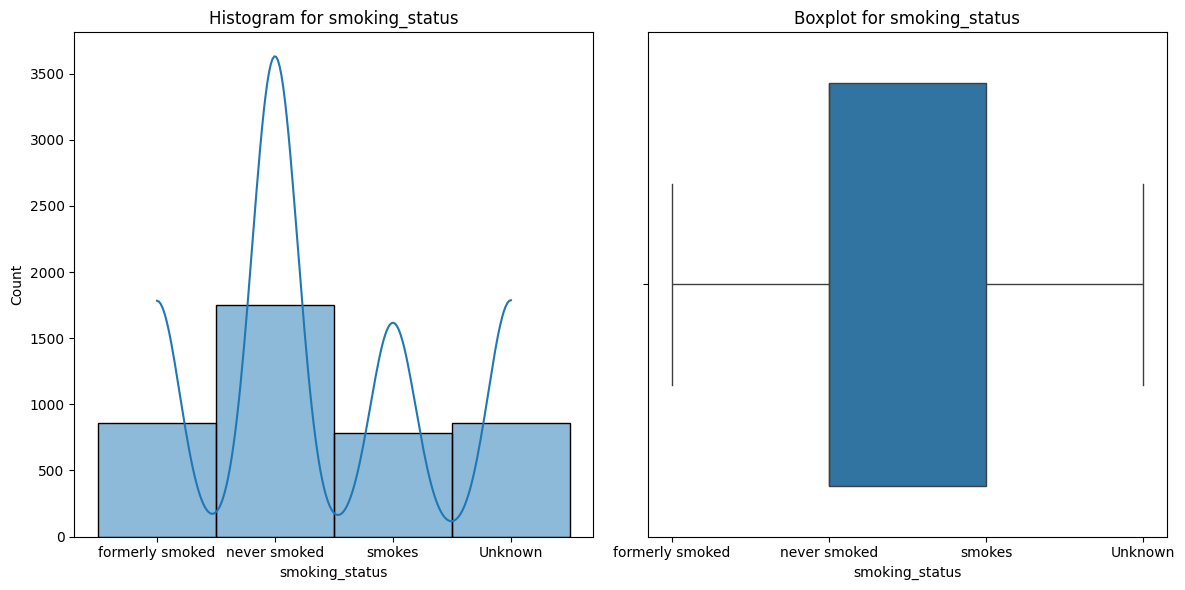

Analysing feature stroke
Skewness of stroke is 3.77945951044013


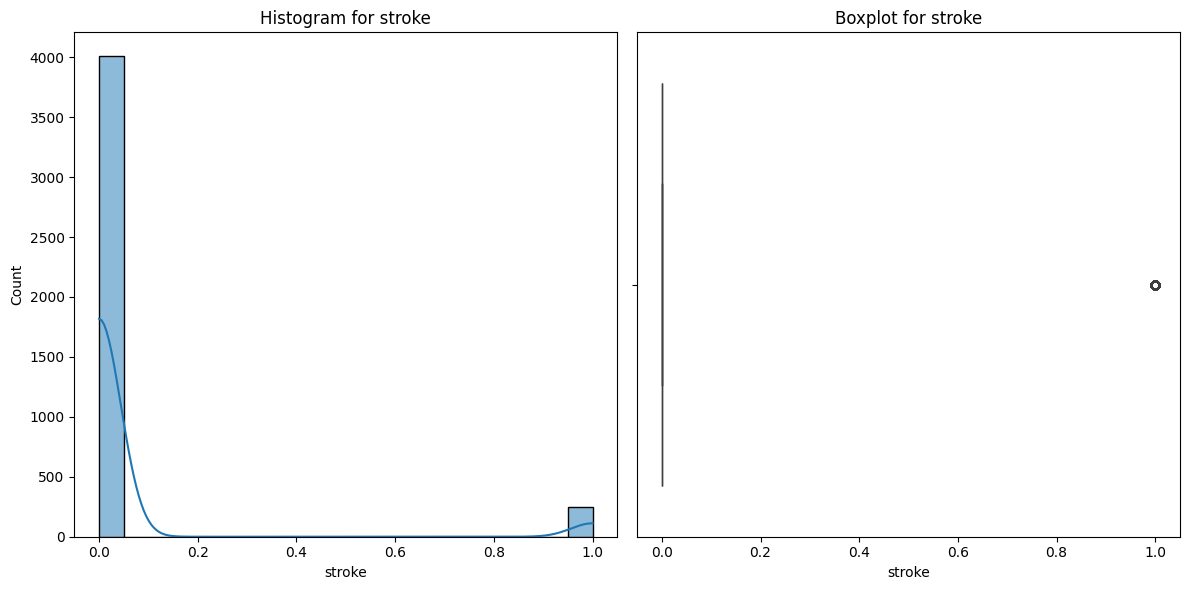

In [16]:
def univariate_analysis(df):
    for column in df.columns:
        print(f"Analysing feature {column}")

        # Only calculate skewness for numeric columns
        if pd.api.types.is_numeric_dtype(df[column]):
            skewness = skew(df[column].dropna())
            print(f"Skewness of {column} is {skewness}")
        else:
            print(f"{column} is categorical/non-numeric, skipping skewness")

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        sns.histplot(df[column], bins=20, kde=True)
        plt.title(f"Histogram for {column}")

        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[column])
        plt.title(f"Boxplot for {column}")

        plt.tight_layout()
        plt.show()

univariate_analysis(stroke_processed_data)

In [18]:
def identify_outliers_for_column(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] <= lower_bound) | (df[column] >= upper_bound)]
    return outliers

def print_outliers_for_column(df, dataset_name):
    for column in df.columns:
        if pd.api.types.is_any_real_numeric_dtype(df[column]):
            print(f"Ouliers for {column} in {dataset_name}")
            outliers = identify_outliers_for_column(df, column)
            print(outliers)
            print("\n")

print_outliers_for_column(stroke_processed_data, 'stroke_dataset')



Ouliers for Unnamed: 0 in stroke_dataset
Empty DataFrame
Columns: [Unnamed: 0, id, gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status, stroke]
Index: []


Ouliers for id in stroke_dataset
Empty DataFrame
Columns: [Unnamed: 0, id, gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status, stroke]
Index: []


Ouliers for age in stroke_dataset
Empty DataFrame
Columns: [Unnamed: 0, id, gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status, stroke]
Index: []


Ouliers for avg_glucose_level in stroke_dataset
      Unnamed: 0     id  gender   age  hypertension  heart_disease  \
0              0   9046    Male  67.0         False           True   
1              1  51676  Female  61.0         False          False   
4              4   1665  Female  79.0          True          False   
5        

Analysing feature Unnamed: 0


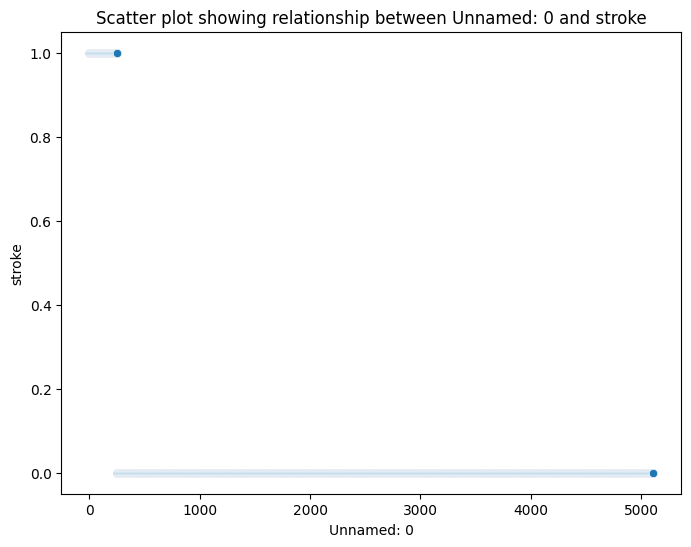

Analysing feature id


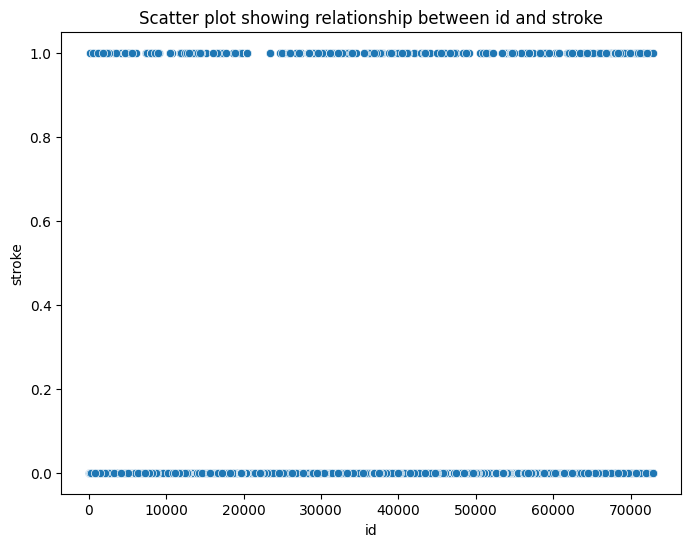

Analysing feature gender


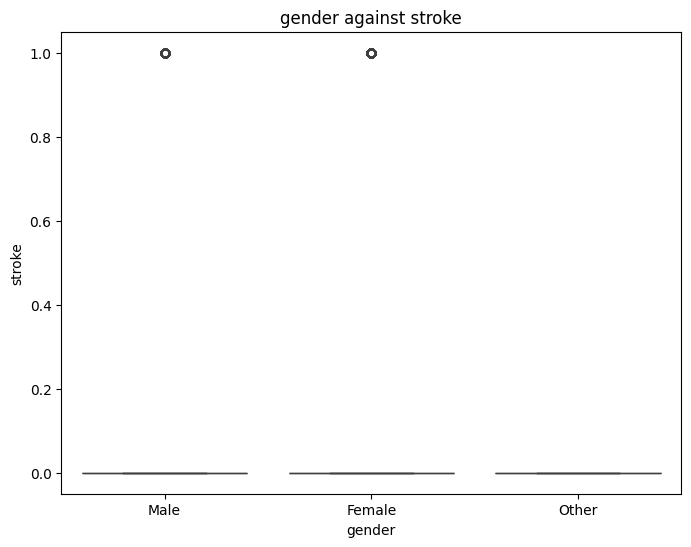

Analysing feature age


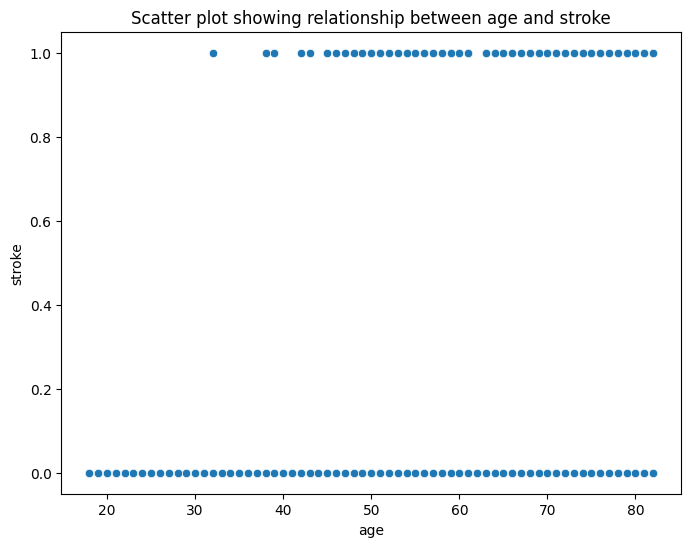

Analysing feature hypertension


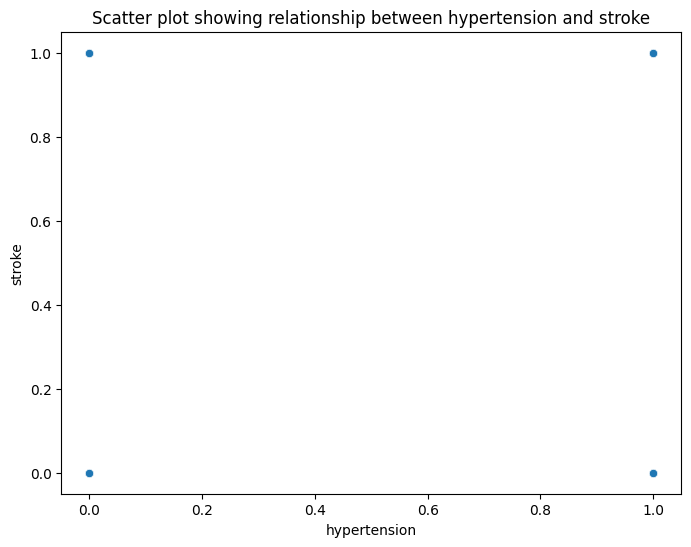

Analysing feature heart_disease


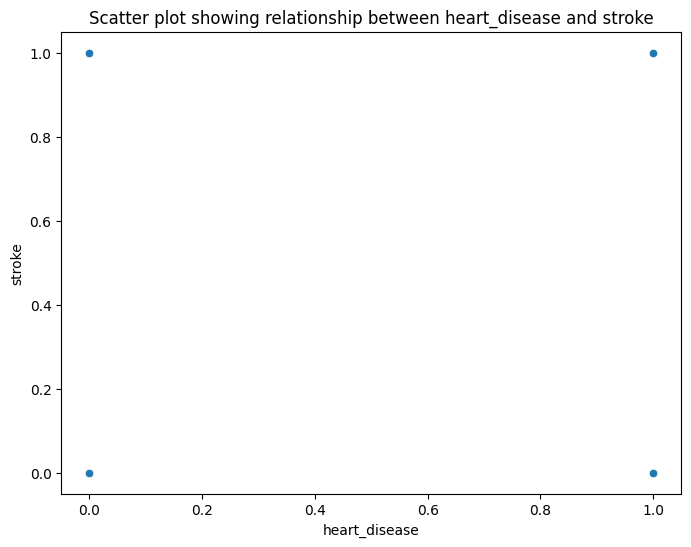

Analysing feature ever_married


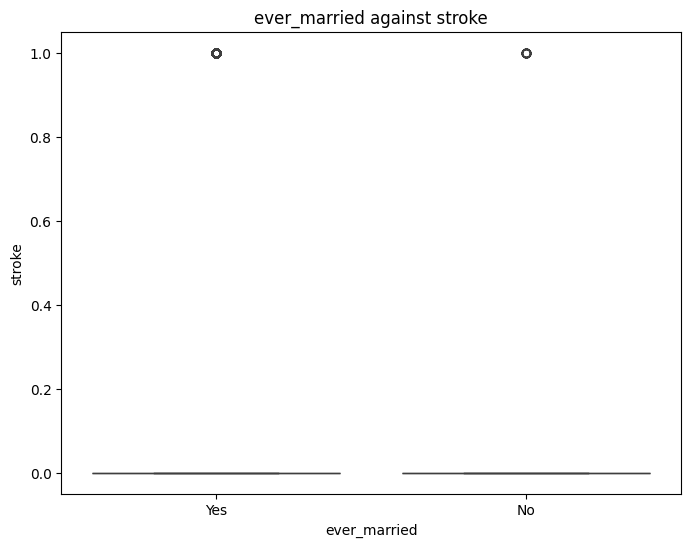

Analysing feature work_type


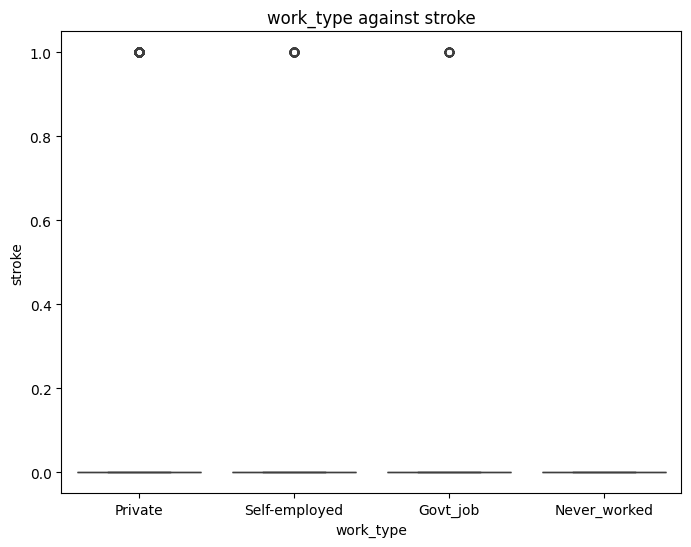

Analysing feature Residence_type


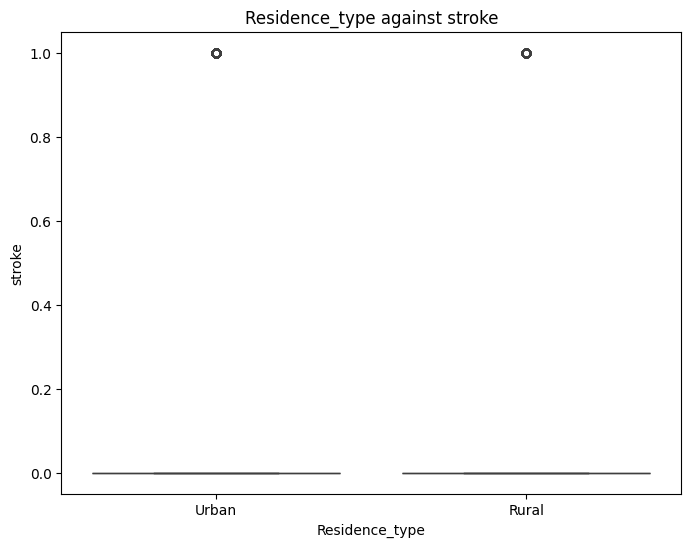

Analysing feature avg_glucose_level


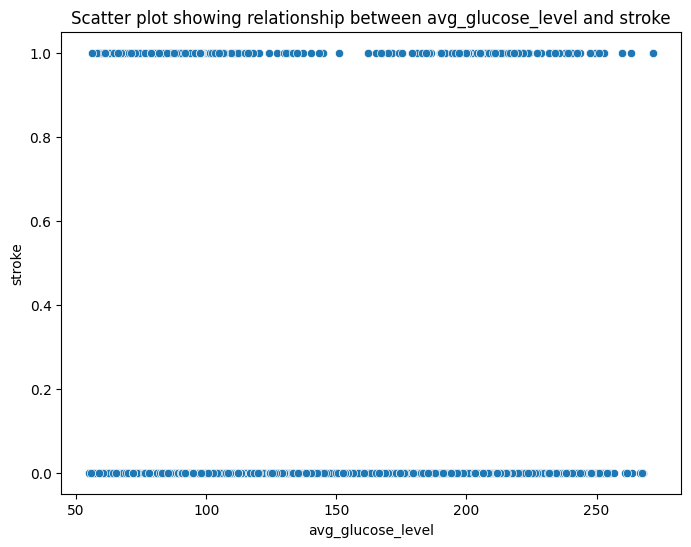

Analysing feature bmi


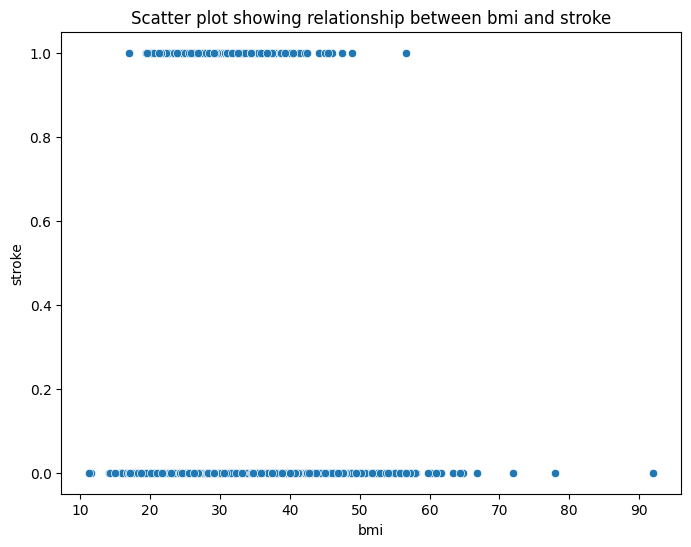

Analysing feature smoking_status


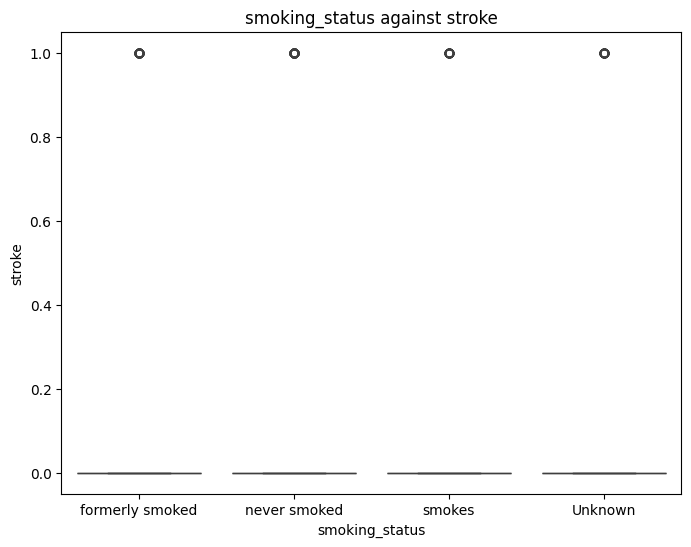

In [21]:
def bivariate_analysis(df, target):
    for column in df.columns:
        if column != target:
            print(f'Analysing feature {column}')

            if pd.api.types.is_numeric_dtype(df[column]):
                plt.figure(figsize=(8 , 6))
                sns.scatterplot(x=df[column], y=df[target])
                plt.title(f"Scatter plot showing relationship between {column} and {target}")
                plt.show()

            elif pd.api.types.is_categorical_dtype(df[column]) or df[column].dtype == 'object':
                plt.figure(figsize=(8 , 6))
                sns.boxplot(x=df[column], y=df[target])
                plt.title(f'{column} against {target}')
                plt.show()

bivariate_analysis(stroke_processed_data, 'stroke')
